In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Colab Notebooks/projet5')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Get the saved csv to df

In [ ]:
import pandas as pd
df = pd.read_csv("df_cleaned.csv")

# Named Entity Recognition

In [ ]:
from spacy import displacy
import spacy
# Load spaCy's English language model
nlp = spacy.load('en_core_web_sm')
def extract_named_entities(text):
    doc = nlp(text)
    entities = []
    for ent in doc.ents:
        entities.append({"entity": ent.text, "label": ent.label_})
    return entities

# Apply NER to all content
df["named_entities"] = df["Content_cleaned"].apply(lambda x: extract_named_entities(x))
print(df[["Content_cleaned", "named_entities"]])

                                      Content_cleaned  \
0   PLTR's notable rise stock price, crucial asses...   
1   Warren Buffett loves dividend stocks, biggest ...   
2   Businesses responsible leading next-big-thing ...   
3   Jeff Bezos' Amazon.com Inc. AMZN reportedly pl...   
4   American EV giant Tesla TSLA launched company'...   
5   Arizona man posing Uber driver allegedly stole...   
6   Stock-split euphoria took Wall Street 2024, br...   
7   Ashok Leyland announces hike prices Business S...   
8   general, main types investing: value investing...   
9   ORCL's Q2 shows weak margins, heavy AI spendin...   
10  Income Statement Data Apple Annual Reports: An...   
11  Income Statement Data Microsoft Annual Reports...   
12  Income Statement Data Amazon Annual Reports: A...   
13  Income Statement Data Tesla Annual Reports: An...   
14  Income Statement Data Uber Annual Reports: Ann...   
15  Income Statement Data Meta Annual Reports: Ann...   
16  Income Statement Data IBM A

In [ ]:
df.to_csv("df_ner.csv", index=False)

# Chunks

In [ ]:
print(df["Content_cleaned"][12])

Income Statement Data Amazon Annual Reports: Annual Report Amazon year unknown states fiscal date ending 2023-12-31. Annual Report Amazon year 2023 states reported currency USD. Annual Report Amazon year 2023 states gross profit 183,837,000,000. Annual Report Amazon year 2023 states total revenue 571,668,000,000. Annual Report Amazon year 2023 states cost revenue 387,831,000,000. Annual Report Amazon year 2023 states costof goods services sold 304,739,000,000. Annual Report Amazon year 2023 states operating income 36,852,000,000. Annual Report Amazon year 2023 states selling general administrative 76,486,000,000. Annual Report Amazon year 2023 states research development 85,622,000,000. Annual Report Amazon year 2023 states operating expenses 84,992,000,000. Annual Report Amazon year 2023 states investment income net 2,949,000,000. Annual Report Amazon year 2023 states net income -3182000000. Annual Report Amazon year 2023 states income 2,493,000,000. Annual Report Amazon year 2023 sta

In [ ]:
from nltk.tokenize import sent_tokenize
import nltk
nltk.download('punkt_tab')
def chunk_text(text, max_length=200):
    sentences = sent_tokenize(text)
    chunks = []
    current_chunk = []

    for sentence in sentences:
      if len(" ".join(current_chunk + [sentence]).split()) <= max_length:
          current_chunk.append(sentence)
      else:
          chunks.append(" ".join(current_chunk))
          current_chunk = [sentence]

    if current_chunk:
        chunks.append(" ".join(current_chunk))

    return chunks

df["chunks"] = df["Content_cleaned"].apply(chunk_text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained Sentence Transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Function to generate embeddings for all chunks
def generate_embeddings(chunks):
    return model.encode(chunks, convert_to_tensor=True)

# Flatten chunks and track their metadata
flattened_chunks = []
metadata = []

for idx, row in df.iterrows():
    for chunk in row["chunks"]:
        flattened_chunks.append(chunk)
        metadata.append({"filename": row["Title"]})

# Generate embeddings
chunk_embeddings = generate_embeddings(flattened_chunks)

print(chunk_embeddings)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tensor([[-0.0815, -0.0872, -0.0180,  ..., -0.1700,  0.0216,  0.0522],
        [-0.0818, -0.0417, -0.0196,  ..., -0.1340,  0.0014,  0.0327],
        [-0.0662, -0.0756,  0.0407,  ..., -0.1588,  0.0312,  0.0012],
        ...,
        [-0.0268, -0.0023, -0.0512,  ..., -0.0574, -0.0023,  0.0425],
        [-0.0315,  0.0056, -0.0328,  ..., -0.0587,  0.0015,  0.0450],
        [-0.0296, -0.0014, -0.0497,  ..., -0.0468,  0.0087,  0.0390]])


In [ ]:
with open(f"chunks.txt", "w", encoding="utf-8") as file:
  file.write(str(chunk_embeddings))

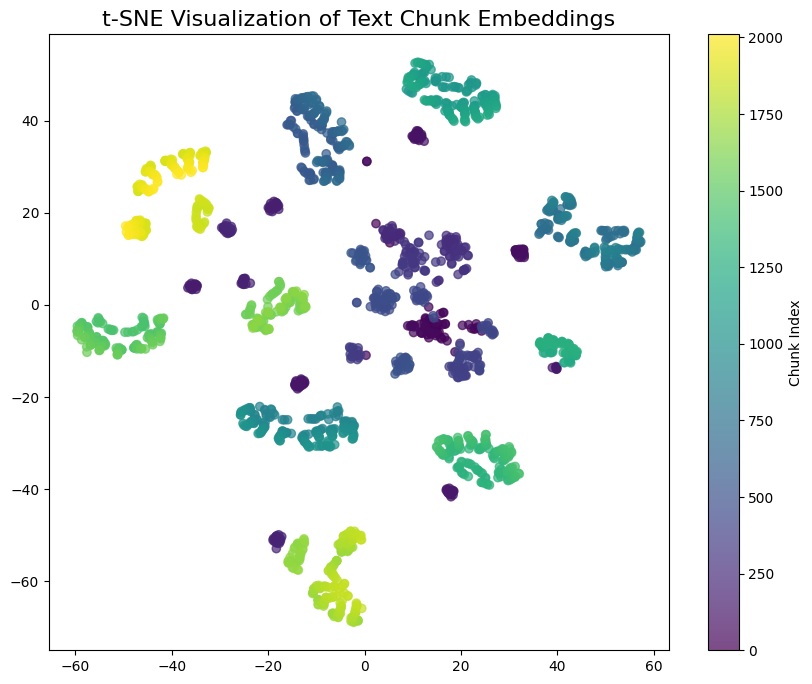

In [ ]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Reduce dimensions for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
reduced_embeddings = tsne.fit_transform(chunk_embeddings.cpu().numpy())

# Visualize embeddings
plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=np.arange(len(metadata)), cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label="Chunk Index")
plt.title("t-SNE Visualization of Text Chunk Embeddings", fontsize=16)
plt.show()

In [ ]:
!pip install plotly
import plotly.express as px
import numpy as np
from sklearn.manifold import TSNE

# Réduction de dimensions avec t-SNE
tsne = TSNE(n_components=3, random_state=42, perplexity=30)
reduced_embeddings = tsne.fit_transform(chunk_embeddings.cpu().numpy())

# Création d'une visualisation 3D interactive avec Plotly
fig = px.scatter_3d(
    x=reduced_embeddings[:, 0],
    y=reduced_embeddings[:, 1],
    z=reduced_embeddings[:, 2],
    color=np.arange(len(metadata)),
    labels={'color': 'Chunk Index'},
    title="t-SNE Visualization of Text Chunk Embeddings"
)

fig.show()


# Cosine Similarity

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Function to retrieve top N similar chunks for a query
def retrieve_similar_chunks(query, top_n=5):
    query_embedding = model.encode([query], convert_to_tensor=True)
    similarities = cosine_similarity(query_embedding.cpu().numpy(), chunk_embeddings.cpu().numpy())[0]
    print("similarities : ", similarities)
    top_indices = np.argsort(similarities)[::-1][:top_n]
    print("top indices : ", top_indices)
    return [(flattened_chunks[i], metadata[i], similarities[i]) for i in top_indices]

# Test the retriever with a sample query
query = "What is the total revenue of microsoft for the year 2019 ?"
results = retrieve_similar_chunks(query)
print(results)

# Display results
for i, (chunk, meta, score) in enumerate(results, 1):
    print(f"Rank {i} | Similarity: {score:.4f}")
    print(f"File: {meta['filename']}")
    print(f"Content: {chunk[:200]}...")
    print("-" * 80)

similarities :  [0.36455265 0.34388083 0.34253484 ... 0.2795812  0.28035533 0.2610152 ]
top indices :  [  88   87   89 1056   82]
[('Annual Report Microsoft year 2019 states comprehensive income net tax 41,154,000,000. Annual Report Microsoft year 2019 states ebit 46,374,000,000. Annual Report Microsoft year 2019 states ebitda 48,274,000,000. Annual Report Microsoft year 2019 states net income 39,240,000,000.Annual Report Microsoft year unknown states fiscal date ending 2018-06-30. Annual Report Microsoft year 2018 states reported currency USD. Annual Report Microsoft year 2018 states gross profit 72,007,000,000. Annual Report Microsoft year 2018 states total revenue 107,222,000,000. Annual Report Microsoft year 2018 states cost revenue 62,776,000,000. Annual Report Microsoft year 2018 states costof goods services sold 38,353,000,000. Annual Report Microsoft year 2018 states operating income 35,058,000,000. Annual Report Microsoft year 2018 states selling general administrative 22,223,

# Save chunks

In [ ]:
#Find how to save chunks so we don't have to run it every time


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


tensor([[-0.0404, -0.0823,  0.0062,  ..., -0.1018,  0.0609,  0.0704],
        [-0.0902, -0.0390,  0.0139,  ..., -0.1135,  0.0477,  0.0062],
        [-0.0427,  0.0239,  0.0178,  ..., -0.1686,  0.0124,  0.0539],
        ...,
        [-0.0438, -0.0039, -0.0515,  ..., -0.0503,  0.0100,  0.0268],
        [-0.0381, -0.0178, -0.0483,  ..., -0.0539,  0.0197,  0.0297],
        [-0.0055,  0.0021, -0.0300,  ..., -0.0508,  0.0240,  0.0552]])
similarities :  [0.1771434  0.26369184 0.29898542 ... 0.26268372 0.32163465 0.32601976]
top indices :  [293 298 282 292 303]
[('Annual Report Microsoft year 2019 states cost revenue 67,908,000,000. Annual Report Microsoft year 2019 states costof goods services sold 42,910,000,000. Annual Report Microsoft year 2019 states operating income 42,959,000,000. Annual Report Microsoft year 2019 states selling general administrative 23,098,000,000. Annual Report Microsoft year 2019 states research development 16,876,000,000.', {'filename': 'Microsoft_income_statement.t

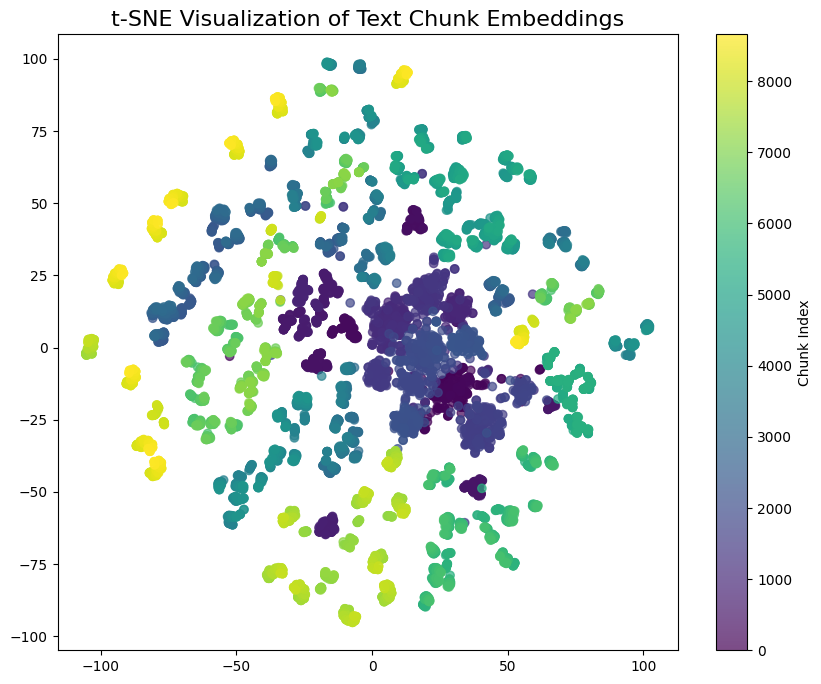

In [ ]:
from nltk.tokenize import sent_tokenize
import nltk
nltk.download('punkt_tab')
def chunk_text(text, max_length=50):
    sentences = sent_tokenize(text)
    chunks = []
    current_chunk = []

    for sentence in sentences:
      if len(" ".join(current_chunk + [sentence]).split()) <= max_length:
          current_chunk.append(sentence)
      else:
          chunks.append(" ".join(current_chunk))
          current_chunk = [sentence]

    if current_chunk:
        chunks.append(" ".join(current_chunk))

    return chunks
df2=df.copy()
df2=df2.drop(columns=["chunks"])
df2["chunks"] = df2["Content_cleaned"].apply(chunk_text)

from sentence_transformers import SentenceTransformer

# Load a pre-trained Sentence Transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Function to generate embeddings for all chunks
def generate_embeddings(chunks):
    return model.encode(chunks, convert_to_tensor=True)

# Flatten chunks and track their metadata
flattened_chunks = []
metadata = []

for idx, row in df2.iterrows():
    for chunk in row["chunks"]:
        flattened_chunks.append(chunk)
        metadata.append({"filename": row["Title"]})

# Generate embeddings
chunk_embeddings2 = generate_embeddings(flattened_chunks)

print(chunk_embeddings2)

from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Reduce dimensions for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
reduced_embeddings2 = tsne.fit_transform(chunk_embeddings2.cpu().numpy())

# Visualize embeddings
plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced_embeddings2[:, 0], reduced_embeddings2[:, 1], c=np.arange(len(metadata)), cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label="Chunk Index")
plt.title("t-SNE Visualization of Text Chunk Embeddings", fontsize=16)

from sklearn.metrics.pairwise import cosine_similarity

# Function to retrieve top N similar chunks for a query
def retrieve_similar_chunks(query, top_n=5):
    query_embedding = model.encode([query], convert_to_tensor=True)
    similarities = cosine_similarity(query_embedding.cpu().numpy(), chunk_embeddings2.cpu().numpy())[0]
    print("similarities : ", similarities)
    top_indices = np.argsort(similarities)[::-1][:top_n]
    print("top indices : ", top_indices)
    return [(flattened_chunks[i], metadata[i], similarities[i]) for i in top_indices]

# Test the retriever with a sample query
query = "What is the total revenue of microsoft for the year 2019 ?"
results = retrieve_similar_chunks(query)
print(results)

# Display results
for i, (chunk, meta, score) in enumerate(results, 1):
    print(f"Rank {i} | Similarity: {score:.4f}")
    print(f"File: {meta['filename']}")
    print(f"Content: {chunk[:200]}...")
    print("-" * 80)

In [ ]:

pip install openai==0.28

In [ ]:
import openai

# Set your OpenAI API key
openai.api_key = "sk-s6evPek-lbUfAcrmP0tdUnoU9hApz6AVnGNkZd4dumT3BlbkFJOFN7RkL9dtLAUGxtf_3JmF82H1KUFFIByXnpLxauAA"

def generate_answer(query, top_n=5):
    # Retrieve the most relevant text chunks
    retrieved_chunks = retrieve_similar_chunks(query, top_n)

    # Extract relevant text from retrieved chunks
    context = "\n\n".join([chunk for chunk, _, _ in retrieved_chunks])

    # Construct the prompt for OpenAI
    prompt = f"""
    You are an AI assistant that answers questions based on provided context.

    Context:
    {context}

    Question:
    {query}

    Answer:
    """

    # Call OpenAI's API
    response = openai.ChatCompletion.create(
        model="gpt-4-turbo",
        messages=[{"role": "system", "content": "You are a helpful AI assistant."},
                  {"role": "user", "content": prompt}]
    )

    # Extract and return the answer
    return response["choices"][0]["message"]["content"].strip()

# Example usage
query = "What is the total revenue of Microsoft for the year 2019?"
answer = generate_answer(query)
print("Generated Answer:", answer)


similarities :  [0.1771434  0.26369184 0.29898542 ... 0.26268372 0.32163465 0.32601976]
top indices :  [293 298 282 292 303]
Generated Answer: The total revenue of Microsoft for the year 2019 is $123,495,000,000.


In [ ]:
pip install networkx matplotlib


In [ ]:
import openai
import matplotlib.pyplot as plt
import re

# Set your OpenAI API key
openai.api_key = "sk-s6evPek-lbUfAcrmP0tdUnoU9hApz6AVnGNkZd4dumT3BlbkFJOFN7RkL9dtLAUGxtf_3JmF82H1KUFFIByXnpLxauAA"

def generate_answer(query, top_n=5):
    # Retrieve the most relevant text chunks
    retrieved_chunks = retrieve_similar_chunks(query, top_n)

    # Extract relevant text from retrieved chunks
    context = "\n\n".join([chunk for chunk, _, _ in retrieved_chunks])

    # Construct the prompt for OpenAI
    prompt = f"""
    You are an AI assistant that extracts and presents numerical data from a given context.

    Context:
    {context}

    Question:
    {query}

    Answer in JSON format:
    {{
        "answer": "Your answer in text format",
        "data": {{"2019": "revenue", "2020": "revenue", "2021": "revenue"}}
    }}
    """

    # Call OpenAI's API
    response = openai.ChatCompletion.create(
        model="gpt-4-turbo",
        messages=[{"role": "system", "content": "You are a helpful AI assistant."},
                  {"role": "user", "content": prompt}]
    )

    # Extract JSON response
    response_text = response["choices"][0]["message"]["content"].strip()

    # Extract structured data using regex (assuming JSON-like output)
    match = re.search(r'{"answer": "(.*?)", "data": {(.*?)}}', response_text)
    if match:
        answer = match.group(1)
        data_str = match.group(2)

        # Convert extracted data to dictionary, handling missing values
        data = {}
        for pair in data_str.split(","):
            year, revenue = pair.strip().replace('"', '').split(":")
            revenue = revenue.strip()
            if revenue.replace(",", "").isdigit():  # Check if revenue is a valid number
                data[year] = float(revenue.replace(",", ""))  # Convert to float
            else:
                print(f"Skipping non-numeric value for {year}: {revenue}")

        return answer, data

    return response_text, {}  # If no structured data is found

def plot_revenue_chart(data):
    if not data:
        print("No valid numerical data found for visualization.")
        return

    # Extract years and revenues
    years = list(data.keys())
    revenues = list(data.values())

    # Create a bar chart
    plt.figure(figsize=(8, 5))
    plt.bar(years, revenues, color="skyblue")
    plt.xlabel("Year")
    plt.ylabel("Total Revenue (in billion $)")
    plt.title("Microsoft Total Revenue (2019-2021)")
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # Show the values on top of the bars
    for i, revenue in enumerate(revenues):
        plt.text(years[i], revenue + 1, f"{revenue/1e9:.2f}B", ha="center", fontsize=10)

    plt.show()

# Example usage
query = "What is the total revenue for Microsoft in 2019? for the year 2020 ? for the year 2021 ?"
answer, data = generate_answer(query)
print("Generated Answer:", answer)

# Visualize the extracted revenue data
plot_revenue_chart(data)

similarities :  [0.1788513  0.27928364 0.29265344 ... 0.24802983 0.29914504 0.2843501 ]
top indices :  [282 293 298 287 283]
Generated Answer: ```json
{
    "answer": "The total revenue for Microsoft in 2019 is not explicitly mentioned in the provided context. For the year 2020, the total revenue is 140,503,000,000 USD, and for the year 2021, the total revenue is 165,936,000,000 USD.",
    "data": {
        "2019": "not available",
        "2020": "140,503,000,000",
        "2021": "165,936,000,000"
    }
}
```
No valid numerical data found for visualization.
